# Section 1.2 — Bubble escape figures

Produces the four figures and two tables referenced by section 1.2:

- **Fig 1.2.1** — $P(x/D)$ and $F^V(x/D)$ overlays
- **Fig 1.2.2** — $D_b$ vs $x/D$ scatter with $\langle D_b\rangle(x/D)$ overlay
- **Fig 1.2.3** — $\phi^V(x/D)$ with bootstrap CI bands
- **Table 1.2.1** — escape statistics with 95% bootstrap CIs
- **Table 1.2.2** — $\phi^V_{\rm edge}$ for cross-check B

Two display modes are provided:
- `MODE = 'data'` — uses only real test runs registered in `SHOTS`
- `MODE = 'data+sim'` — also draws synthetic shots from per-condition Cox/IPP fits, for sensitivity studies and provisional figure rendering when only a handful of repeats are available

Add new real runs in the `SHOTS` block.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA_DIR = Path('/home/zl483/bubbles/out')   # change if your data lives elsewhere


## Configuration

Edit `SHOTS` to add real test runs. Each entry is

    (label, filename, U_p [mm/s], b, V_nom [µL], colour)

Files must be CSVs with columns `X_world, Y_world, R_world` in mm.


In [2]:
# --- analysis parameters ---
MODE         = 'data+sim'        # 'data' or 'data+sim'
B            = 2000          # bootstrap iterations
CI           = 95            # CI level (%)
D_RING       = 40.0          # mm, ring diameter for normalisation
YD_GRID      = np.linspace(4, 18, 100)        # phi^V evaluation grid
YD_BIN_EDGES = np.linspace(4, 18, 9)          # bins for <D>(x/D)
BIN_CENTERS  = 0.5 * (YD_BIN_EDGES[:-1] + YD_BIN_EDGES[1:])

# --- synthetic shots (only used when MODE = 'data+sim') ---
N_SIM_PER_COND = 3           # extra synthetic shots per condition
SIM_N_DRAW     = 'match'     # 'match' = same N as real shots; or an integer

# --- registered shots ---
# Group multiple shots at the same (U_p, b) by giving them the same label.
SHOTS = [
    # label,     filename,         U_p, b, V_nom, colour
    ('120, b=1', 'bubbles_03.csv', 120, 1, 20, '#1f77b4'),
    ('120, b=3', 'bubbles_01.csv', 120, 3, 40, '#d62728'),
    ('200, b=1', 'bubbles_06.csv', 200, 1, 20, '#2ca02c'),
    ('200, b=3', 'bubbles_05.csv', 200, 3, 40, '#9467bd')
    # ('120, b=3', 'bubbles_07.csv', 200, 1, 20, '#d62728')  # excluded as ill-run
]


## Load real shots

Shots sharing a `label` are pooled into a single condition (used for plots and the per-condition bootstrap).

In [3]:
def load_shot(fn):
    df = pd.read_csv(DATA_DIR / fn)
    return df['R_world'].values, df['Y_world'].values, df['X_world'].values

conds = {}   # label -> dict with pooled R, Y, X arrays + metadata
for lab, fn, Up, b, Vnom, col in SHOTS:
    R, Y, X = load_shot(fn)
    if lab not in conds:
        conds[lab] = dict(R=[], Y=[], X=[], Up=Up, b=b, Vnom=Vnom, col=col, files=[])
    conds[lab]['R'].append(R)
    conds[lab]['Y'].append(Y)
    conds[lab]['X'].append(X)
    conds[lab]['files'].append(fn)

for lab, d in conds.items():
    d['R'] = np.concatenate(d['R'])
    d['Y'] = np.concatenate(d['Y'])
    d['X'] = np.concatenate(d['X'])
    print(f"{lab:<12}  N = {len(d['R']):>4}  files = {d['files']}")


120, b=1      N =  326  files = ['bubbles_03.csv']
120, b=3      N =  348  files = ['bubbles_01.csv']
200, b=1      N =  101  files = ['bubbles_06.csv']
200, b=3      N =   74  files = ['bubbles_05.csv']


## Optional: synthetic shots from a per-condition resampling model

When `MODE = 'data+sim'`, additional synthetic shots are generated per condition by resampling triples $(X, Y, R_b)$ with replacement from the pooled real data for that condition. This is a *nonparametric* surrogate that preserves the joint distribution (and therefore the $\rho(D, Y)$ correlation, the size dependence of escape distance, etc) without imposing any IPP assumption.

This is a Cox-process surrogate, not new physical information: it duplicates the empirical structure with sample-size fluctuations. Use it for visual sensitivity checks and uncertainty propagation, **not** for hypothesis tests that need fresh draws.


In [4]:
def simulate_shot(R, Y, X, n_draw, rng):
    # Nonparametric Cox-process surrogate: resample (X, Y, R) triples.
    n = len(R)
    idx = rng.integers(0, n, n_draw)
    return R[idx], Y[idx], X[idx]

sim_conds = {}
if MODE == 'data+sim':
    rng = np.random.default_rng(1)
    for lab, d in conds.items():
        sim_R, sim_Y, sim_X = [], [], []
        n_per = len(d['R']) if SIM_N_DRAW == 'match' else int(SIM_N_DRAW)
        for _ in range(N_SIM_PER_COND):
            r, y, x = simulate_shot(d['R'], d['Y'], d['X'], n_per, rng)
            sim_R.append(r); sim_Y.append(y); sim_X.append(x)
        sim_conds[lab] = dict(R=np.concatenate(sim_R),
                              Y=np.concatenate(sim_Y),
                              X=np.concatenate(sim_X),
                              Up=d['Up'], b=d['b'], Vnom=d['Vnom']*N_SIM_PER_COND,
                              col=d['col'], files=[f'sim×{N_SIM_PER_COND}'])
        print(f"{lab:<12}  sim N = {len(sim_conds[lab]['R']):>5}  (N_real × {N_SIM_PER_COND})")
else:
    print(f"MODE = {MODE!r}  →  no synthetic shots")

# active pool used by downstream cells: real only, or real+sim merged per label
active = {lab: dict(d) for lab, d in conds.items()}
if MODE == 'data+sim':
    for lab, ds in sim_conds.items():
        active[lab]['R'] = np.concatenate([active[lab]['R'], ds['R']])
        active[lab]['Y'] = np.concatenate([active[lab]['Y'], ds['Y']])
        active[lab]['X'] = np.concatenate([active[lab]['X'], ds['X']])
        active[lab]['Vnom'] = active[lab]['Vnom'] + ds['Vnom']


120, b=1      sim N =   978  (N_real × 3)
120, b=3      sim N =  1044  (N_real × 3)
200, b=1      sim N =   303  (N_real × 3)
200, b=3      sim N =   222  (N_real × 3)


## Bootstrap utilities

Pointwise nonparametric bootstrap on rows of $(X, Y, R)$. The same routine produces CIs for scalars (Table 1.2.1) and pointwise bands for curves (Fig 1.2.3).


In [5]:
def boot_indices(n, B, rng):
    return rng.integers(0, n, size=(B, n))

def ci(arr, level=CI, axis=0):
    a = (100 - level) / 2
    return np.nanpercentile(arr, [a, 50, 100 - a], axis=axis)

def cum_volume_curve(Y, V, Vnom, grid):
    # phi^V on a grid: 1 - cum(V)/Vnom interpolated at grid points.
    order = np.argsort(Y)
    Y_s = Y[order]
    cV  = np.cumsum(V[order])
    cum = np.interp(grid, Y_s, cV, left=0.0, right=cV[-1])
    return 1 - cum / Vnom

def binned_mean(Y, vals, edges):
    # Mean of `vals` in disjoint bins of Y; NaN for empty bins.
    out = np.full(len(edges) - 1, np.nan)
    for k in range(len(edges) - 1):
        m = (Y >= edges[k]) & (Y < edges[k+1])
        if m.any():
            out[k] = vals[m].mean()
    return out


## Table 1.2.1 — Escape statistics with 95% bootstrap CIs

In [6]:
rng = np.random.default_rng(42)

def shot_stats(R, Y, X, Vnom):
    V  = 4/3 * np.pi * R**3      # uL per event
    Dum = 2 * R * 1000
    YD  = Y / D_RING
    Vsum = V.sum()
    order = np.argsort(Y)
    cumF = np.cumsum(V[order]) / Vsum
    return dict(
        N        = len(R),
        Vtot     = Vsum,
        VVnom    = Vsum / Vnom,
        medD     = np.median(Dum),
        cnt_LeD  = np.median(YD),
        vol_LeD  = (Y[order][np.searchsorted(cumF, 0.5)]) / D_RING,
        sigX     = X.std(ddof=1),
        rho      = stats.spearmanr(R, Y).statistic,
    )

def boot_table(R, Y, X, Vnom, B, rng):
    n = len(R)
    idx = boot_indices(n, B, rng)
    rows = []
    for b in range(B):
        i = idx[b]
        rows.append(shot_stats(R[i], Y[i], X[i], Vnom))
    keys = rows[0].keys()
    return {k: np.array([r[k] for r in rows]) for k in keys}

table_rows = []
for lab, d in active.items():
    pt = shot_stats(d['R'], d['Y'], d['X'], d['Vnom'])
    bt = boot_table(d['R'], d['Y'], d['X'], d['Vnom'], B, rng)
    row = {'condition': lab, 'N': pt['N']}
    for k in ['Vtot', 'VVnom', 'medD', 'cnt_LeD', 'vol_LeD', 'sigX', 'rho']:
        lo, _, hi = ci(bt[k])
        row[k]            = pt[k]
        row[f'{k}_lo']    = lo
        row[f'{k}_hi']    = hi
    table_rows.append(row)

T = pd.DataFrame(table_rows).set_index('condition')

def fmt(row, key, dec=2):
    return f"{row[key]:.{dec}f} [{row[f'{key}_lo']:.{dec}f}, {row[f'{key}_hi']:.{dec}f}]"

T_display = pd.DataFrame({
    'N'              : T['N'].astype(int),
    'V_count (uL)'   : [fmt(r, 'Vtot', 2)    for _, r in T.iterrows()],
    'V/V_nom'        : [fmt(r, 'VVnom', 2)   for _, r in T.iterrows()],
    'med D (um)'     : [fmt(r, 'medD', 0)    for _, r in T.iterrows()],
    'L_e/D  (count)' : [fmt(r, 'cnt_LeD', 2) for _, r in T.iterrows()],
    'L_e^V/D (vol)'  : [fmt(r, 'vol_LeD', 2) for _, r in T.iterrows()],
    'sigma_X (mm)'   : [fmt(r, 'sigX', 2)    for _, r in T.iterrows()],
    'rho(D, Y)'      : [fmt(r, 'rho', 2)     for _, r in T.iterrows()],
}, index=T.index)

print(f"Mode: {MODE}   B = {B}   CI = {CI}%")
T_display


Mode: data+sim   B = 2000   CI = 95%


,N,V_count (uL),V/V_nom,med D (um),L_e/D (count),L_e^V/D (vol),sigma_X (mm),"rho(D, Y)"
condition,,,,,,,,
"120, b=1",1304,"28.19 [26.35, 30.21]","0.35 [0.33, 0.38]","299 [281, 299]","16.86 [16.62, 17.00]","15.59 [15.38, 15.66]","4.29 [4.06, 4.52]","-0.57 [-0.61, -0.53]"
"120, b=3",1392,"106.51 [88.98, 124.83]","0.67 [0.56, 0.78]","281 [263, 299]","16.91 [16.81, 17.03]","8.56 [8.35, 9.70]","6.61 [6.36, 6.86]","-0.80 [-0.82, -0.78]"
"200, b=1",404,"23.02 [21.12, 25.12]","0.29 [0.26, 0.31]","439 [422, 457]","18.19 [17.93, 18.32]","17.69 [17.55, 17.75]","3.82 [3.42, 4.19]","-0.38 [-0.45, -0.29]"
"200, b=3",296,"72.18 [60.11, 85.02]","0.45 [0.38, 0.53]","597 [562, 659]","16.69 [16.60, 16.79]","15.45 [14.55, 15.74]","3.25 [2.96, 3.52]","-0.52 [-0.62, -0.41]"


## Fig 1.2.1 — $P(x/D)$ and $F^V(x/D)$ overlays

Left panel: count pdf $P(x/D)$ (KDE). Right panel: volume-weighted cumulative $F^V(x/D)$ as a step function over actual events.


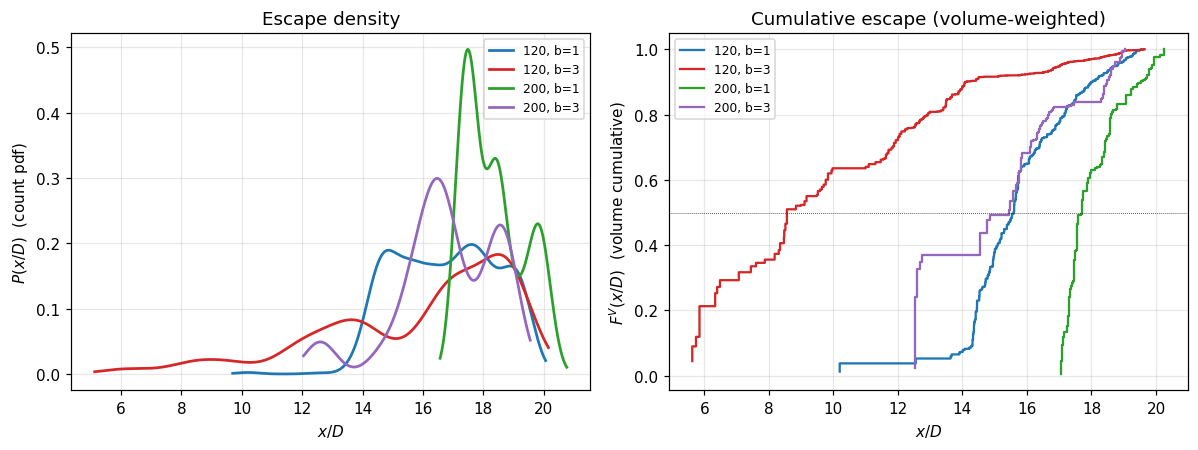

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

for lab, d in active.items():
    Y, R = d['Y'], d['R']
    V    = 4/3 * np.pi * R**3
    YD   = Y / D_RING

    # count pdf via KDE
    kde = stats.gaussian_kde(YD)
    xs  = np.linspace(YD.min() - 0.5, YD.max() + 0.5, 400)
    ax[0].plot(xs, kde(xs), color=d['col'], lw=1.8, label=lab)

    # cumulative volume fraction as event-by-event step
    order = np.argsort(Y)
    cumF  = np.cumsum(V[order]) / V.sum()
    ax[1].step(YD[order], cumF, where='post', color=d['col'], lw=1.5, label=lab)

ax[0].set_xlabel(r'$x / D$'); ax[0].set_ylabel(r'$P(x/D)$  (count pdf)')
ax[0].set_title('Escape density'); ax[0].legend(fontsize=8)

ax[1].set_xlabel(r'$x / D$'); ax[1].set_ylabel(r'$F^V(x/D)$  (volume cumulative)')
ax[1].set_title('Cumulative escape (volume-weighted)')
ax[1].axhline(0.5, color='k', lw=0.5, ls=':')
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# save as pdf
fig.savefig(DATA_DIR / f"escape_pdf_{MODE}.pdf")


## Fig 1.2.2 — $D_b$ vs $x/D$ with $\langle D_b\rangle(x/D)$ overlay

Each panel: scatter of all escape events for one condition + binned mean diameter with bootstrap CI band. All four conditions are also overlaid for the comparative point made in §1.2.4.


/home/zl483/bubbles/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


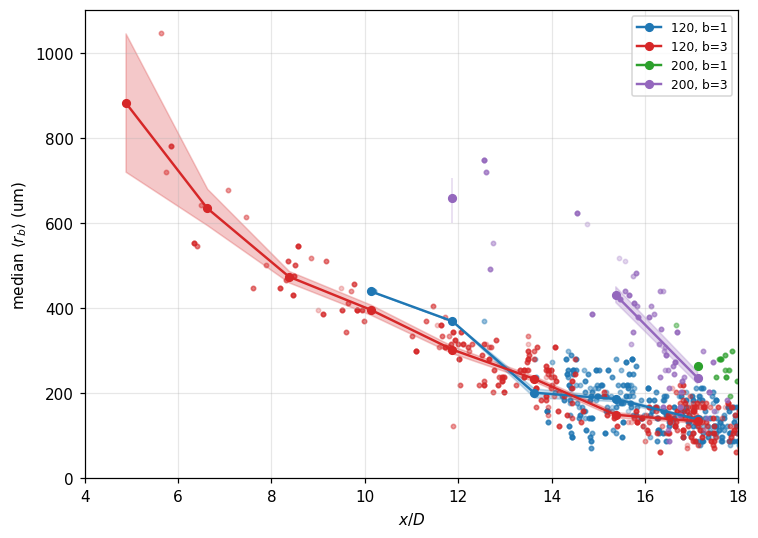

In [8]:
rng = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(7, 5))

for lab, d in active.items():
    Y, R = d['Y'], d['R']
    Rum = R * 1000
    YD = Y / D_RING

    ax.scatter(YD, Rum, s=8, alpha=0.25, color=d['col'])

    # bootstrap binned <r_b>
    n = len(R); idx = boot_indices(n, B, rng)
    mat = np.empty((B, len(BIN_CENTERS)))
    for bi in range(B):
        i = idx[bi]
        mat[bi] = binned_mean(YD[i], Rum[i], YD_BIN_EDGES)
    lo, md_, hi = ci(mat)

    ax.fill_between(BIN_CENTERS, lo, hi, color=d['col'], alpha=0.25)
    ax.plot(BIN_CENTERS, md_, 'o-', color=d['col'], lw=1.6, ms=5, label=lab)

    ax.set_xlabel(r'$x / D$'); ax.set_ylabel(r'median $\langle r_b \rangle$ (um)')
    ax.set_xlim(4, 18)
    ax.set_ylim(0, 1100)
    ax.legend(fontsize=8)
    fig.tight_layout()
    # plt.show()

# save to pdf
fig.savefig(DATA_DIR / f"escape_median_radius_{MODE}.pdf")


## Fig 1.2.3 — $\phi^V(x/D)$ with 95% bootstrap CI bands

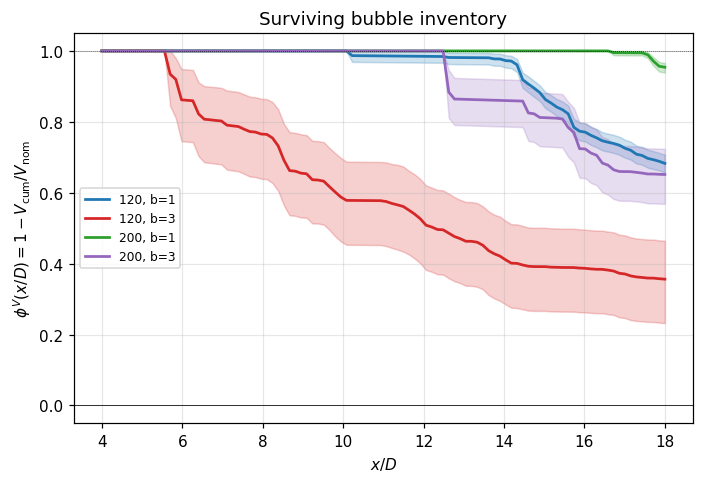

In [9]:
rng = np.random.default_rng(11)
fig, ax = plt.subplots(figsize=(6.5, 4.5))

phi_edge_summary = {}
for lab, d in active.items():
    R, Y = d['R'], d['Y']; Vnom = d['Vnom']
    V    = 4/3 * np.pi * R**3
    YD   = Y / D_RING

    # bootstrap the phi^V curve pointwise
    n = len(R); idx = boot_indices(n, B, rng)
    mat = np.empty((B, len(YD_GRID)))
    for bi in range(B):
        i = idx[bi]
        mat[bi] = cum_volume_curve(YD[i], V[i], Vnom, YD_GRID)
    lo, md_, hi = ci(mat)

    ax.fill_between(YD_GRID, lo, hi, color=d['col'], alpha=0.22)
    ax.plot(YD_GRID, md_, color=d['col'], lw=1.8, label=lab)

    phi_edge_summary[lab] = (md_[-1], lo[-1], hi[-1])

ax.axhline(0, color='k', lw=0.5)
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel(r'$x / D$'); ax.set_ylabel(r'$\phi^V(x/D) = 1 - V_{\rm cum}/V_{\rm nom}$')
ax.set_title('Surviving bubble inventory')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# save to pdf
fig.savefig(DATA_DIR / f"escape_phiV_{MODE}.pdf")

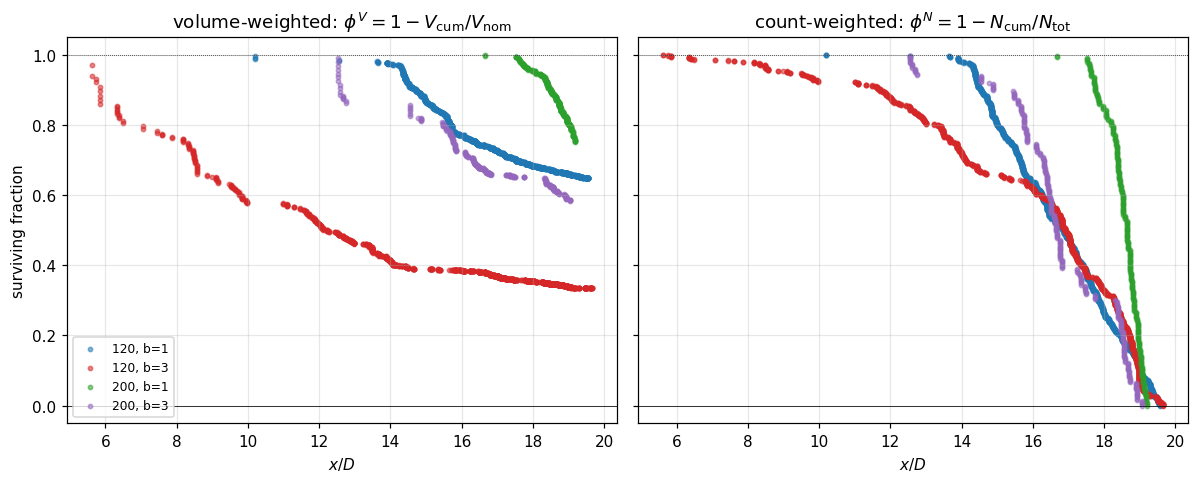

In [10]:
rng = np.random.default_rng(11)
fig, (axV, axN) = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

phi_edge_summary = {}
edge_x = YD_GRID[-1]   # keep Table 1.2.2's x/D = 18 convention

for lab, d in active.items():
    R, Y = d['R'], d['Y']; Vnom = d['Vnom']
    V    = 4/3 * np.pi * R**3
    YD   = Y / D_RING

    # cumulative stats at actual sorted data points — no interpolation
    order = np.argsort(YD)
    YDs   = YD[order]
    cV    = np.cumsum(V[order])
    cN    = np.arange(1, len(YDs) + 1)
    phiV  = 1 - cV / Vnom
    phiN  = 1 - cN / len(YDs)

    axV.scatter(YDs, phiV, s=8, color=d['col'], alpha=0.55, label=lab)
    axN.scatter(YDs, phiN, s=8, color=d['col'], alpha=0.55, label=lab)

    # scalar bootstrap of phi^V at x/D = edge_x (preserves Table 1.2.2 input)
    n         = len(R)
    idx       = boot_indices(n, B, rng)
    in_edge   = YD[idx] <= edge_x
    cV_edge   = np.where(in_edge, V[idx], 0.0).sum(axis=1)
    edge_boot = 1 - cV_edge / Vnom
    a = (100 - CI) / 2
    lo, md_, hi = np.nanpercentile(edge_boot, [a, 50, 100 - a])
    phi_edge_summary[lab] = (md_, lo, hi)

for ax in (axV, axN):
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(1, color='k', lw=0.5, ls=':')
    ax.set_xlabel(r'$x / D$')

axV.set_ylabel('surviving fraction')
axV.set_title(r'volume-weighted: $\phi^V = 1 - V_{\rm cum}/V_{\rm nom}$')
axN.set_title(r'count-weighted: $\phi^N = 1 - N_{\rm cum}/N_{\rm tot}$')
axV.legend(fontsize=8, loc='lower left')

fig.tight_layout()
plt.show()

# save to pdf
fig.savefig(DATA_DIR / f"escape_phiVN_{MODE}.pdf")

## Table 1.2.2 — $\phi^V_{\rm edge}$ at the imaging boundary

Used for cross-check B (§1.5.2): if no destruction, $\phi^V_{\rm edge}$ should equal $V_{\rm fit}/V_{\rm nom}$ from §1.3.6 / Table 1.2 of the chapter.


In [11]:
# V_fit/V_nom values transcribed from Table 1.2 of the chapter draft
V_FIT_NOM = {
    '120, b=1': [21.7/20, 24.7/20],
    '120, b=3': [18.5/40, 31.5/40],
    '200, b=1': None,    # excluded from joint fit
    '200, b=3': None,
}

rows = []
for lab, (md_, lo, hi) in phi_edge_summary.items():
    vfit = V_FIT_NOM.get(lab)
    vfit_str = ', '.join(f'{v:.2f}' for v in vfit) if vfit else '—'
    rows.append({
        'condition'                : lab,
        r'phi^V_edge (this work)'  : f'{md_:.2f} [{lo:.2f}, {hi:.2f}]',
        'V_fit/V_nom (Table 1.2)'  : vfit_str,
    })
pd.DataFrame(rows).set_index('condition')


,phi^V_edge (this work),V_fit/V_nom (Table 1.2)
condition,,
"120, b=1","0.68 [0.66, 0.71]","1.08, 1.23"
"120, b=3","0.36 [0.23, 0.46]","0.46, 0.79"
"200, b=1","0.95 [0.94, 0.97]",—
"200, b=3","0.65 [0.57, 0.72]",—


## Adding more real runs

1. Drop the CSV into `/mnt/user-data/uploads/` (or wherever `DATA_DIR` points).
2. Append an entry to `SHOTS` above. Use the same `label` as an existing condition to pool the runs together, or a new label for a new $(U_p, b)$ cell.
3. Re-run from the loading cell.

Pooled labels share a colour and contribute to a single bootstrap distribution per condition.


## Switching modes

- `MODE = 'data'`  → uses only real test runs (default; the version that should go in the chapter)
- `MODE = 'data+sim'`  → adds `N_SIM_PER_COND` synthetic shots per condition by resampling the real pool. Useful for:
  - sanity checks that figure shapes are not artefacts of small N
  - propagating sample-size uncertainty before more shots are run

Synthetic shots are nonparametric surrogates of the empirical joint distribution. They do **not** carry new information and should never be used for hypothesis tests in the chapter.
